In [1]:
# ================================
# IMPORT LIBRARY
# ================================
import tensorflow as tf
import numpy as np
import os

from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ================================
# MOUNT GOOGLE DRIVE
# ================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ================================
# DATASET CONFIG
# ================================
BASE_PATH = "/content/drive/MyDrive/MobileNet-TA/dataset_classification"

IMG_SIZE = (224,224)
BATCH_SIZE = 32
NUM_CLASSES = 3

In [4]:
# import cv2
# import numpy as np
# from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

# def preprocessing_with_filter(img):

#     # convert ke uint8 (karena generator kadang float)
#     img = img.astype(np.uint8)

#     # ================================
#     # GAUSSIAN BLUR (Noise reduction)
#     # ================================
#     img = cv2.GaussianBlur(img, (3,3), 0)

#     # ================================
#     # CLAHE (improve contrast)
#     # ================================
#     lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
#     l,a,b = cv2.split(lab)

#     clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
#     l = clahe.apply(l)

#     lab = cv2.merge((l,a,b))
#     img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

#     # ================================
#     # MobileNet preprocessing
#     # ================================
#     img = preprocess_input(img)

#     return img

In [5]:
# ================================
# DATA AUGMENTATION
# ================================

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    horizontal_flip=True,
    brightness_range=(0.8,1.2),
    width_shift_range=0.1,
    height_shift_range=0.12,
    zoom_range=0.15,
    # shear_range=0.08,
    # fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [6]:
# ================================
# LOAD DATASET
# ================================

train_gen = train_datagen.flow_from_directory(
    f"{BASE_PATH}/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    f"{BASE_PATH}/valid",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    f"{BASE_PATH}/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2558 images belonging to 3 classes.
Found 301 images belonging to 3 classes.
Found 311 images belonging to 3 classes.


In [7]:
# ================================
# CLASS WEIGHT
# ================================

class_labels = train_gen.classes
unique_classes = np.unique(class_labels)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=class_labels
)

class_weights = dict(zip(unique_classes,class_weights_array))

print("Class Weights:",class_weights)

Class Weights: {np.int32(0): np.float64(0.5526031540289479), np.int32(1): np.float64(1.7544581618655692), np.int32(2): np.float64(1.6118462507876496)}


In [8]:
# ================================
# LOAD PRETRAINED MODEL
# ================================

base_model = MobileNetV3Large(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [9]:
# ================================
# BUILD MODEL
# ================================
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate

gap = GlobalAveragePooling2D()(base_model.output)
gmp = GlobalMaxPooling2D()(base_model.output)

x = Concatenate()([gap, gmp])

x = BatchNormalization()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)

output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 3,496,579 (13.34 MB)

 Trainable params: 496,387 (1.89 MB)

 Non-trainable params: 3,000,192 (11.44 MB)

In [10]:
# ================================
# COMPILE MODEL
# ================================

from tensorflow.keras.losses import CategoricalCrossentropy

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
# ================================
# CALLBACK
# ================================

callbacks = [

    ModelCheckpoint(
        "/content/drive/MyDrive/MobileNet-TA/mobilenet_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    # ReduceLROnPlateau(
    #     monitor="val_loss",
    #     factor=0.2,
    #     patience=3,
    #     min_lr=1e-6
    # )

]

In [12]:
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

# freeze mobilenet
base_model.trainable = False

# compile
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
# ================================
# TRAINING PHASE 1
# ================================
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 863ms/step - accuracy: 0.6532 - loss: 0.8890
Epoch 1: val_accuracy improved from None to 0.75083, saving model to /content/drive/MyDrive/MobileNet-TA/mobilenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MobileNet-TA/mobilenet_best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.7232 - loss: 0.7157 - val_accuracy: 0.7508 - val_loss: 0.7196
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.8023 - loss: 0.4918
Epoch 2: val_accuracy improved from 0.75083 to 0.83056, saving model to /content/drive/MyDrive/MobileNet-TA/mobilenet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MobileNet-TA/mobilenet_best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 54s 680ms/step - accuracy: 0.8041 - loss: 0.4970 - val_accuracy: 0.8306 - val_loss: 0.4312
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.8092 - loss: 0.4587
Epoch 3: val_accuracy improved from 0.83056 to 0.84385, saving model 

In [14]:
# ================================
# FINE TUNING
# ================================

from tensorflow.keras.losses import CategoricalCrossentropy

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [15]:
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

loss_fn = CategoricalCrossentropy(label_smoothing=0.05)

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=1000,
    alpha=1e-6
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
#Training phase 2 (35 epoch)
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=35,
    callbacks=callbacks
)

Epoch 1/35
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.8847 - loss: 0.2684
Epoch 1: val_accuracy did not improve from 0.89701
80/80 ━━━━━━━━━━━━━━━━━━━━ 99s 938ms/step - accuracy: 0.8882 - loss: 0.2697 - val_accuracy: 0.8804 - val_loss: 0.2851
Epoch 2/35
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.8889 - loss: 0.2803
Epoch 2: val_accuracy did not improve from 0.89701
80/80 ━━━━━━━━━━━━━━━━━━━━ 52s 650ms/step - accuracy: 0.8917 - loss: 0.2851 - val_accuracy: 0.8771 - val_loss: 0.3163
Epoch 3/35
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.8794 - loss: 0.2842
Epoch 3: val_accuracy did not improve from 0.89701
80/80 ━━━━━━━━━━━━━━━━━━━━ 50s 622ms/step - accuracy: 0.8831 - loss: 0.2832 - val_accuracy: 0.8771 - val_loss: 0.3380
Epoch 4/35
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.8924 - loss: 0.2612
Epoch 4: val_accuracy did not improve from 0.89701
80/80 ━━━━━━━━━━━━━━━━━━━━ 50s 627ms/step - accuracy: 0.8909 - loss: 0.2706 - val_accuracy: 0.8771

In [17]:
model = tf.keras.models.load_model(
"/content/drive/MyDrive/MobileNet-TA/mobilenet_best.keras"
)

In [18]:
# ================================
# MODEL EVALUATION
# ================================

y_pred_prob = model.predict(test_gen)

y_pred = np.argmax(y_pred_prob,axis=1)

y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())

print("Class labels:",class_names)

print("\n--- CLASSIFICATION REPORT ---")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

acc = accuracy_score(y_true,y_pred)

print("Test Accuracy:",acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step
Class labels: ['bekerja', 'idle', 'meninggalkan_area']

--- CLASSIFICATION REPORT ---
                   precision    recall  f1-score   support

          bekerja     0.9000    0.9692    0.9333       195
             idle     0.8511    0.7407    0.7921        54
meninggalkan_area     0.9630    0.8387    0.8966        62

         accuracy                         0.9035       311
        macro avg     0.9047    0.8496    0.8740       311
     weighted avg     0.9041    0.9035    0.9015       311

Test Accuracy: 0.9035369774919614


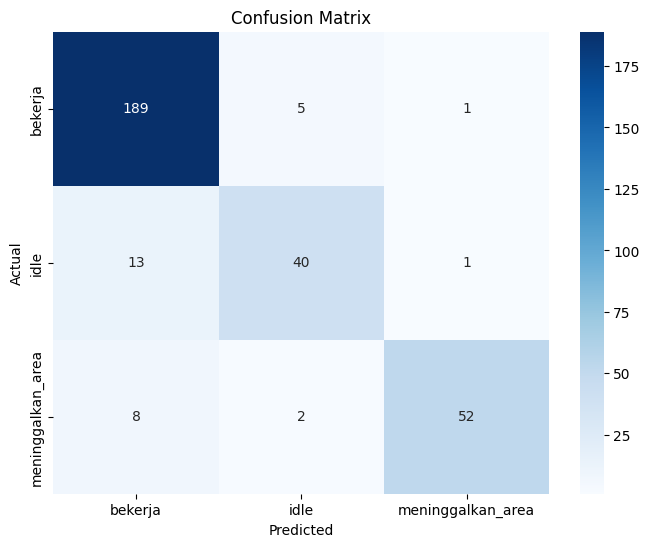

In [19]:
# ================================
# CONFUSION MATRIX
# ================================

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Text(0.5, 1.0, 'Accuracy')

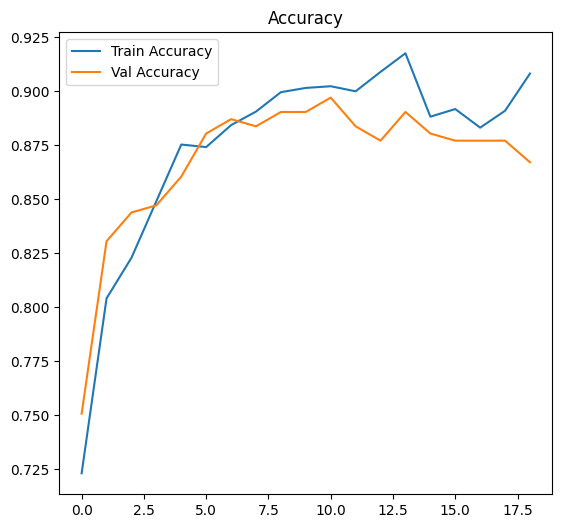

In [20]:
# ================================
# TRAINING GRAPH
# ================================

acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(epochs_range,acc,label="Train Accuracy")
plt.plot(epochs_range,val_acc,label="Val Accuracy")
plt.legend()
plt.title("Accuracy")



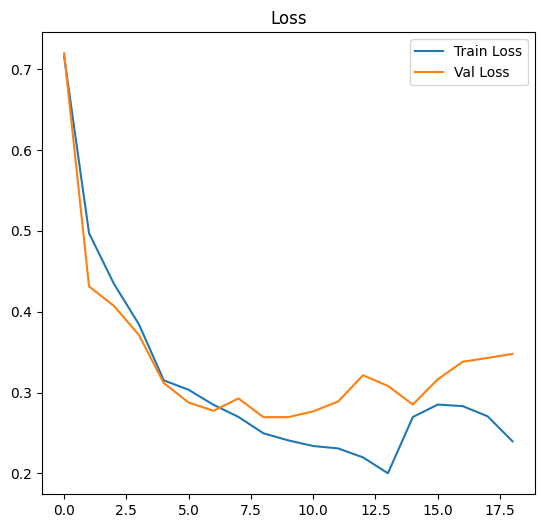

In [21]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,2)
plt.plot(epochs_range,loss,label="Train Loss")
plt.plot(epochs_range,val_loss,label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()